In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv("data/data.csv", sep=",", low_memory=False)
df.head(5)

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation


In [36]:
df.shape

(22676, 12)

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22676 entries, 0 to 22675
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             22676 non-null  float64
 1   Apartment type    22676 non-null  str    
 2   Metro station     22676 non-null  str    
 3   Minutes to metro  22676 non-null  float64
 4   Region            22676 non-null  str    
 5   Number of rooms   22676 non-null  float64
 6   Area              22676 non-null  float64
 7   Living area       22676 non-null  float64
 8   Kitchen area      22676 non-null  float64
 9   Floor             22676 non-null  float64
 10  Number of floors  22676 non-null  int64  
 11  Renovation        22676 non-null  str    
dtypes: float64(7), int64(1), str(4)
memory usage: 3.2 MB


In [38]:
df.isna().sum()

Price               0
Apartment type      0
Metro station       0
Minutes to metro    0
Region              0
Number of rooms     0
Area                0
Living area         0
Kitchen area        0
Floor               0
Number of floors    0
Renovation          0
dtype: int64

In [39]:
# Убираем нереалистичные значения и дубликаты
df = df.drop_duplicates()

df = df[df["Area"] >= 10]
df = df[df["Area"] <= 300]
df = df[df["Price"] >= 1_000_000]
df = df[df["Price"] <= 300_000_000]
df = df[df["Floor"] > 0]
df = df[df["Number of floors"] > 0]
df = df[df["Floor"] <= df["Number of floors"]]
df = df[df["Number of rooms"] >= 0]
df = df[df["Living area"] <= df["Area"]]
df = df[df["Kitchen area"] <= df["Area"]]

In [40]:
# Переименуем колонки
df.columns = [
    "price",
    "apartment_type",
    "metro_station",
    "minutes_to_metro",
    "region",
    "rooms",
    "area",
    "living_area",
    "kitchen_area",
    "floor",
    "total_floors",
    "renovation"
]

In [41]:
df.info()

<class 'pandas.DataFrame'>
Index: 18818 entries, 0 to 22675
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             18818 non-null  float64
 1   apartment_type    18818 non-null  str    
 2   metro_station     18818 non-null  str    
 3   minutes_to_metro  18818 non-null  float64
 4   region            18818 non-null  str    
 5   rooms             18818 non-null  float64
 6   area              18818 non-null  float64
 7   living_area       18818 non-null  float64
 8   kitchen_area      18818 non-null  float64
 9   floor             18818 non-null  float64
 10  total_floors      18818 non-null  int64  
 11  renovation        18818 non-null  str    
dtypes: float64(7), int64(1), str(4)
memory usage: 2.8 MB


In [42]:
df.describe()

,price,minutes_to_metro,rooms,area,living_area,kitchen_area,floor,total_floors
count,1.881800e+04,18818.000000,18818.000000,18818.000000,18818.000000,18818.000000,18818.00000,18818.000000
mean,2.593316e+07,11.851472,1.993304,63.630390,34.641769,11.863864,8.54129,17.033319
std,4.038454e+07,6.271157,1.423860,43.656126,25.976042,6.485375,7.08613,9.715341
min,1.420000e+06,0.000000,0.000000,10.000000,2.000000,1.000000,1.00000,1.000000
25%,7.073206e+06,7.000000,1.000000,37.000000,17.400000,8.300000,3.00000,11.000000
50%,1.158464e+07,11.000000,2.000000,52.235000,28.200000,10.400000,7.00000,16.000000
75%,2.300000e+07,15.000000,3.000000,74.700000,42.100000,13.900000,12.00000,20.000000
max,3.000000e+08,60.000000,12.000000,300.000000,250.000000,122.000000,92.00000,97.000000


In [43]:
df.shape

(18818, 12)

In [44]:
df[["rooms", "floor"]] = df[["rooms", "floor"]].astype(int)

In [45]:
df.info()

<class 'pandas.DataFrame'>
Index: 18818 entries, 0 to 22675
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             18818 non-null  float64
 1   apartment_type    18818 non-null  str    
 2   metro_station     18818 non-null  str    
 3   minutes_to_metro  18818 non-null  float64
 4   region            18818 non-null  str    
 5   rooms             18818 non-null  int64  
 6   area              18818 non-null  float64
 7   living_area       18818 non-null  float64
 8   kitchen_area      18818 non-null  float64
 9   floor             18818 non-null  int64  
 10  total_floors      18818 non-null  int64  
 11  renovation        18818 non-null  str    
dtypes: float64(5), int64(3), str(4)
memory usage: 2.8 MB


In [46]:
features = [
    "apartment_type",
    "metro_station",
    "minutes_to_metro",
    "rooms",
    "area",
    "living_area",
    "kitchen_area",
    "floor",
    "total_floors",
    "renovation"
]

In [47]:
categorical_features = [
    "apartment_type",
    "metro_station",
    "renovation"
]

In [48]:
numeric_features = [
    "minutes_to_metro",
    "rooms",
    "area",
    "living_area",
    "kitchen_area",
    "floor",
    "total_floors"
]

## Обработка выбросов

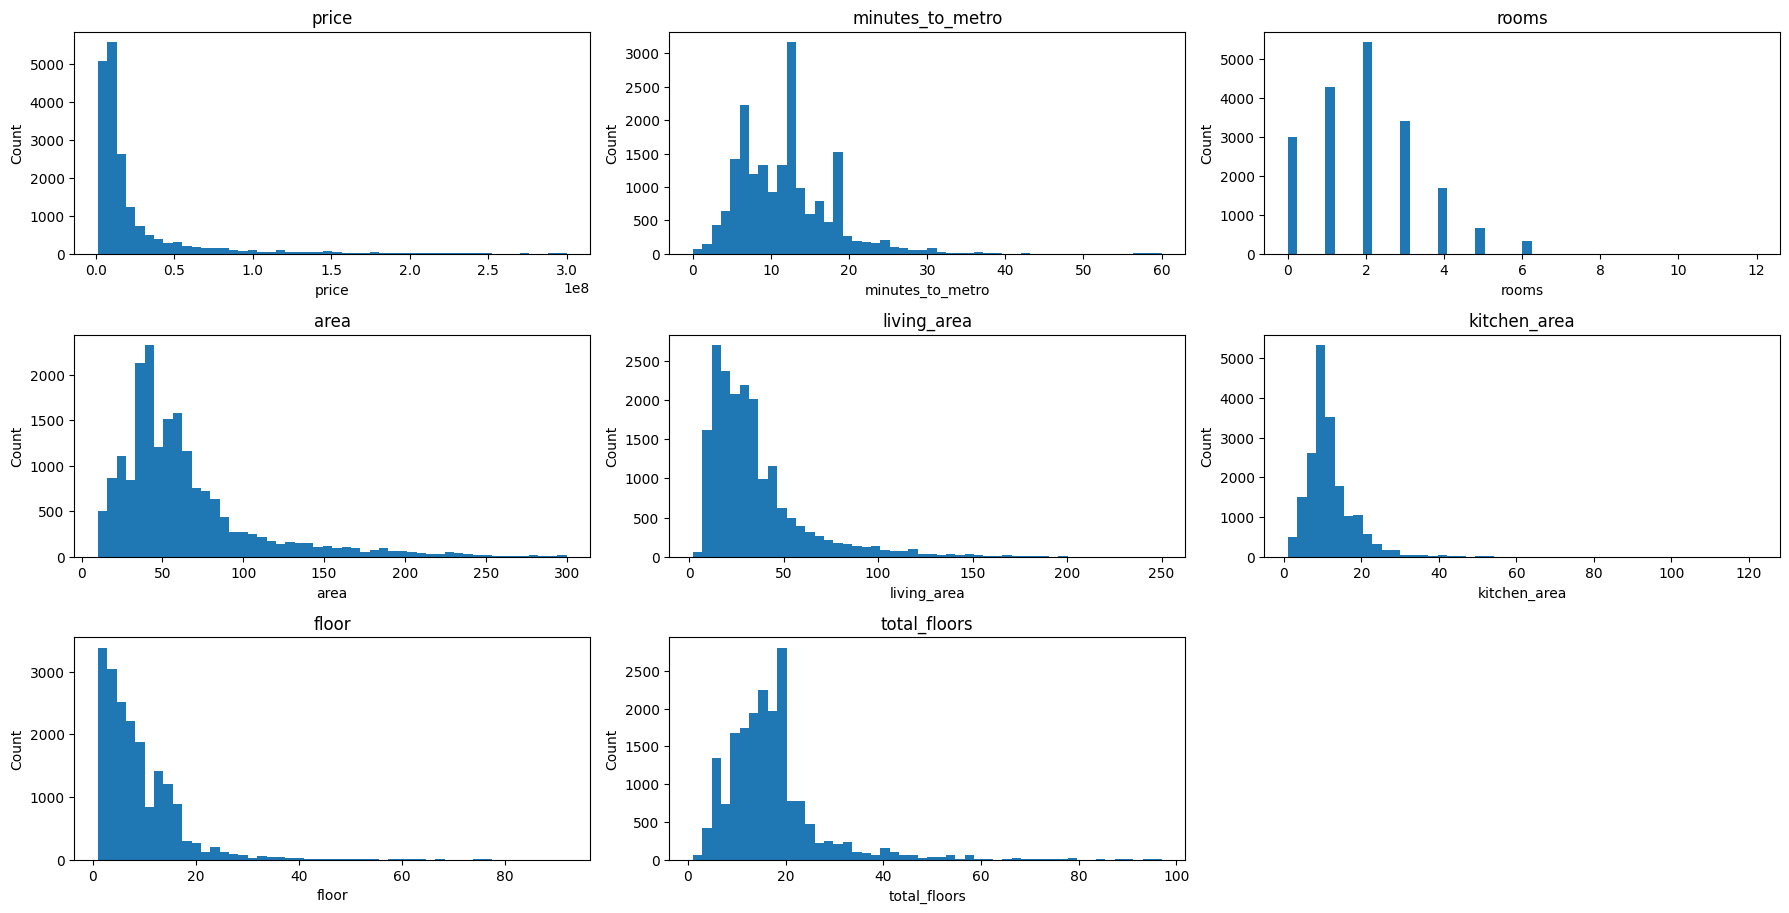

In [49]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18, 30))

for i, col in enumerate(numeric_cols):
    plt.subplot(10, 3, i + 1)
    plt.hist(df[col].dropna(), bins=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [50]:
df = df[
    (df["price"] >= df["price"].quantile(0.01)) &
    (df["price"] <= df["price"].quantile(0.99))
]

df = df[
    (df["area"] >= df["area"].quantile(0.01)) &
    (df["area"] <= df["area"].quantile(0.99))
]

df = df[
    (df["kitchen_area"] >= df["kitchen_area"].quantile(0.01)) &
    (df["kitchen_area"] <= df["kitchen_area"].quantile(0.99))
]

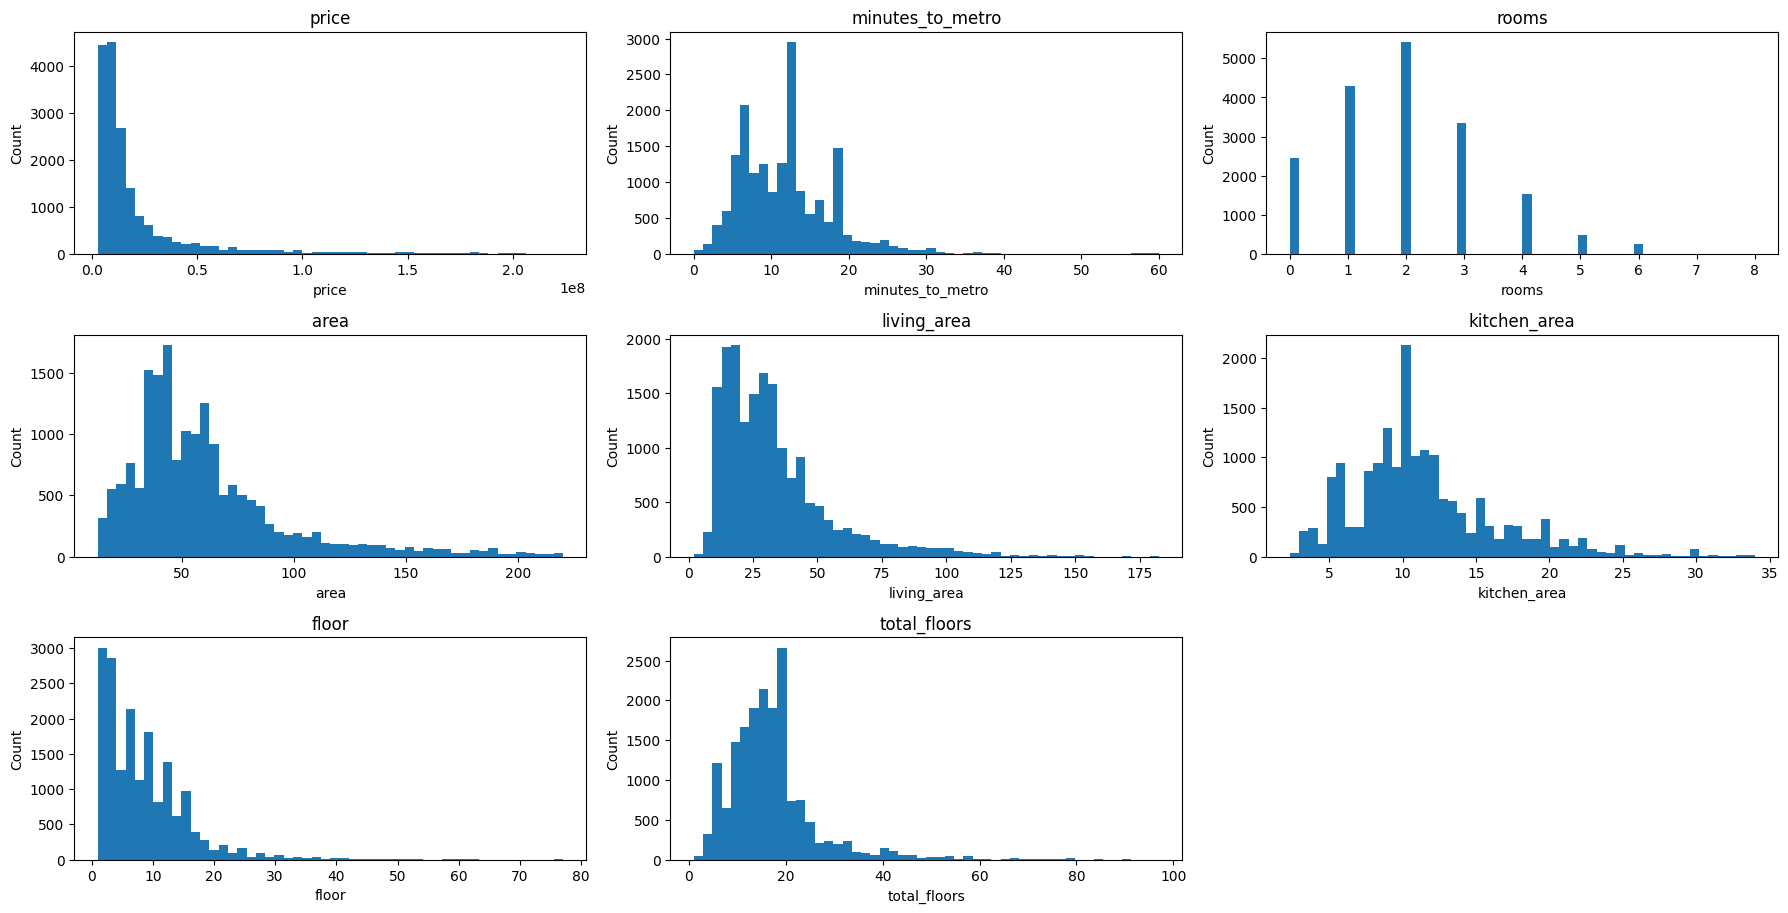

In [51]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18, 30))

for i, col in enumerate(numeric_cols):
    plt.subplot(10, 3, i + 1)
    plt.hist(df[col].dropna(), bins=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Обработка признаков и создание новых

In [52]:
df["floor_ratio"] = df["floor"] / df["total_floors"]
df["room_density"] = df["rooms"] / df["area"]
df["living_ratio"] = df["living_area"] / df["area"]
df["kitchen_ratio"] = df["kitchen_area"] / df["area"]

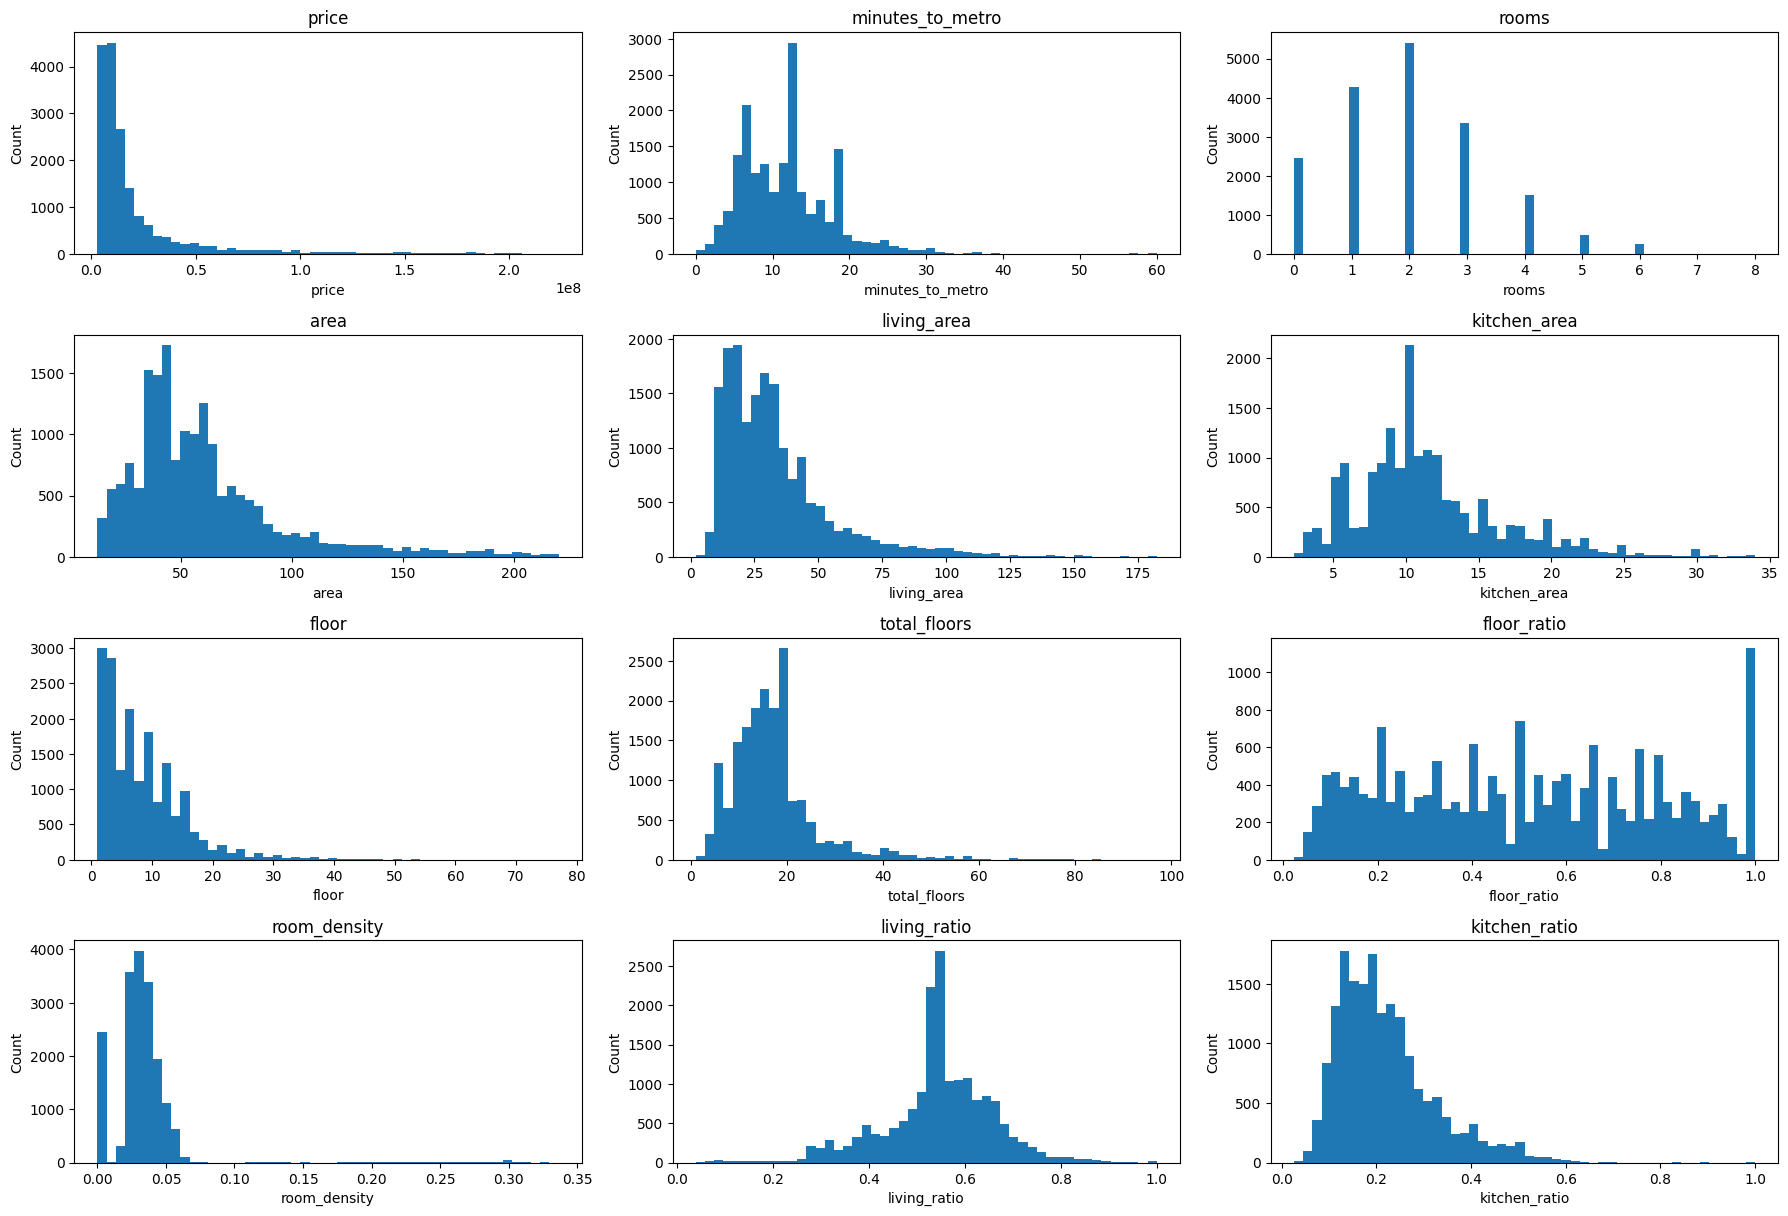

In [53]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18, 30))

for i, col in enumerate(numeric_cols):
    plt.subplot(10, 3, i + 1)
    plt.hist(df[col].dropna(), bins=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [54]:
df.info()

<class 'pandas.DataFrame'>
Index: 17731 entries, 0 to 22675
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             17731 non-null  float64
 1   apartment_type    17731 non-null  str    
 2   metro_station     17731 non-null  str    
 3   minutes_to_metro  17731 non-null  float64
 4   region            17731 non-null  str    
 5   rooms             17731 non-null  int64  
 6   area              17731 non-null  float64
 7   living_area       17731 non-null  float64
 8   kitchen_area      17731 non-null  float64
 9   floor             17731 non-null  int64  
 10  total_floors      17731 non-null  int64  
 11  renovation        17731 non-null  str    
 12  floor_ratio       17731 non-null  float64
 13  room_density      17731 non-null  float64
 14  living_ratio      17731 non-null  float64
 15  kitchen_ratio     17731 non-null  float64
dtypes: float64(9), int64(3), str(4)
memory usage: 3.2 MB


In [55]:
df.head(5)

,price,apartment_type,metro_station,minutes_to_metro,region,rooms,area,living_area,kitchen_area,floor,total_floors,renovation,floor_ratio,room_density,living_ratio,kitchen_ratio
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1,30.6,11.1,8.5,25,25,Cosmetic,1.000000,0.032680,0.362745,0.277778
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1,49.2,20.0,10.0,6,15,European-style renovation,0.400000,0.020325,0.406504,0.203252
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1,44.7,16.2,13.1,10,25,Cosmetic,0.400000,0.022371,0.362416,0.293065
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1,35.1,16.0,11.0,12,33,European-style renovation,0.363636,0.028490,0.455840,0.313390
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1,37.7,15.2,4.0,5,5,Without renovation,1.000000,0.026525,0.403183,0.106101


In [56]:
df.to_csv("data/clean_data.csv", index=None)